<a href="https://www.kaggle.com/code/lanamedea/notebookthebi-project?scriptVersionId=235898795" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/twitter-airline-sentiment/Tweets.csv
/kaggle/input/twitter-airline-sentiment/database.sqlite


In [2]:
# Data exploring
import pandas as pd
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

print("\nShape of the dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nInfo:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())


print("\nMissing values per column:")
print(df.isnull().sum())


print("\nNumber of duplicated rows:")
print(df.duplicated().sum())


Shape of the dataset:
(14640, 15)

Data types:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# 1. Remove missing values
df = df.dropna()
print("After dropping missing values:", df.shape)

# 2. Remove duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# 3. Check the data types of all columns
print("\nData Types:")
print(df.dtypes)

# 4. Show the unique sentiment labels and their counts
print("\nUnique values in sentiment column:")
print(df['airline_sentiment'].value_counts())

# 5. Clean the text column:
#    - Convert text to lowercase
#    - Remove URLs
#    - Remove numbers and special characters
#    - Remove extra spaces

import re

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # Remove numbers & special chars
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces
    return text.strip()

# Apply cleaning function to the text column
df['clean_text'] = df['text'].apply(clean_text)

# Show sample cleaned text
print("\nSample cleaned tweets:")
print(df[['text', 'clean_text']].head(3))

After dropping missing values: (2, 15)
After removing duplicates: (2, 15)

Data Types:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Unique values in sentiment column:
airline_sentiment
negative    2
Name: count, dtype: int64

Sample cleaned tweets:
                                                   text  \
4206  @united So what do you offer now that my fligh...   
9536  @USAirways Seriously doubt that as I am still ...   

   

In [4]:
#Text processing
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Apply stemming to cleaned text
df['stemmed_text'] = df['clean_text'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))

In [5]:
#text processing
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Add custom words if needed
custom_include_words = ['delay', 'cancel', 'refund']  # words you want to make sure are included
filtered_stopwords = [word for word in stop_words if word not in custom_include_words]

# Remove stop words
df['no_stopwords'] = df['stemmed_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in filtered_stopwords]))

In [6]:
#synonym mapping as text processing
synonym_dict = {
    "flights": "flight",
    "delays": "delay",
    "cancelled": "cancel",
    "canceled": "cancel"
}

def map_synonyms(text):
    return ' '.join([synonym_dict.get(word, word) for word in text.split()])

df['normalized_text'] = df['no_stopwords'].apply(map_synonyms)

In [7]:

from nltk.tokenize import word_tokenize

# Tokenize each tweet
df['tokens'] = df['normalized_text'].apply(word_tokenize)

In [8]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
df['sentiment_binary'] = lb.fit_transform(df['airline_sentiment'])  # Example: positive → 1, negative → 0

In [9]:
from collections import Counter

# Count words in all tweets
all_words = ' '.join(df['normalized_text']).split()
word_freq = Counter(all_words)

# Show most common terms
print("Most common terms:", word_freq.most_common(10))

Most common terms: [('flight', 2), ('unit', 1), ('offer', 1), ('wa', 1), ('cancel', 1), ('im', 1), ('strand', 1), ('away', 1), ('home', 1), ('work', 1)]


In [10]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


# Load the dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Drop missing and duplicate rows
df = df.dropna()
df = df.drop_duplicates()

# Initialize cleaning tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Define the processing function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-z\s]", "", text)  # remove numbers and punctuation
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply the function to create 'processed_text'
df['processed_text'] = df['text'].apply(clean_text)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

texts = df['processed_text']  # This column should now exist

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(texts)

# Convert to readable DataFrame (optional)
term_doc_df = pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())
print(term_doc_df.head())

   away  cancel  doubt  flight  gate  home  im  insid  offer  serious  sit  \
0     1       1      0       2     0     1   1      0      1        0    0   
1     0       0      1       0     1     0   0      1      0        1    1   

   still  strand  unit  usairway  work  
0      0       1     1         0     1  
1      1       0     0         1     0  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF term-document matrix
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(texts)

# Convert to DataFrame (optional)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Show the matrix
print(tfidf_df.head())

       away    cancel     doubt   flight      gate      home        im  \
0  0.288675  0.288675  0.000000  0.57735  0.000000  0.288675  0.288675   
1  0.000000  0.000000  0.377964  0.00000  0.377964  0.000000  0.000000   

      insid     offer   serious       sit     still    strand      unit  \
0  0.000000  0.288675  0.000000  0.000000  0.000000  0.288675  0.288675   
1  0.377964  0.000000  0.377964  0.377964  0.377964  0.000000  0.000000   

   usairway      work  
0  0.000000  0.288675  
1  0.377964  0.000000  


In [13]:
import pandas as pd
import sqlite3
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import emoji


# Connect to the database
conn = sqlite3.connect('/kaggle/input/twitter-airline-sentiment/database.sqlite')

# Load the tweet table
df_sql = pd.read_sql_query("SELECT * FROM Tweets", conn)

# Check the available columns
print(df_sql.columns)

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tweets = [
    "flight was delayed due to weather",
    "very helpful staff and smooth boarding",
    "worst experience ever with airline",
    "great service and on time departure",
    "rude agent cancelled my ticket with no explanation"
]


vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_tfidf = vectorizer.fit_transform(tweets)


tfidf_table = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_table.index = [f"Tweet {i+1}" for i in range(len(tweets))]


print(tfidf_table.head(10)) 

tfidf_table.to_csv("tfidf_table.csv", index=True)

            agent  airline  boarding  cancelled  delayed  departure  \
Tweet 1  0.000000  0.00000       0.0   0.000000  0.57735        0.0   
Tweet 2  0.000000  0.00000       0.5   0.000000  0.00000        0.0   
Tweet 3  0.000000  0.57735       0.0   0.000000  0.00000        0.0   
Tweet 4  0.000000  0.00000       0.0   0.000000  0.00000        0.5   
Tweet 5  0.447214  0.00000       0.0   0.447214  0.00000        0.0   

         experience  explanation   flight  great  helpful      rude  service  \
Tweet 1     0.00000     0.000000  0.57735    0.0      0.0  0.000000      0.0   
Tweet 2     0.00000     0.000000  0.00000    0.0      0.5  0.000000      0.0   
Tweet 3     0.57735     0.000000  0.00000    0.0      0.0  0.000000      0.0   
Tweet 4     0.00000     0.000000  0.00000    0.5      0.0  0.000000      0.5   
Tweet 5     0.00000     0.447214  0.00000    0.0      0.0  0.447214      0.0   

         smooth  staff    ticket  time  weather    worst  
Tweet 1     0.0    0.0  0.000000 

In [15]:
tfidf_table.to_csv("tfidf_table.csv", index=True)

In [16]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Function to clean and process text
def clean_text_with_emoji(text):
    text = emoji.demojize(text)  # Convert emoji to text like :smile:
    text = text.lower()  # Lowercase
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-z:\s]", "", text)  # Keep words + emoji tags like :smile:
    tokens = word_tokenize(text)  # Tokenize
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply to SQL data
df_sql['processed_text'] = df_sql['text'].apply(clean_text_with_emoji)

# Show result
print(df_sql[['text', 'processed_text']].head(3))

                                                text  \
0  @JetBlue's new CEO seeks the right balance to ...   
1  @JetBlue is REALLY getting on my nerves !! 😡😡 ...   
2  @united yes. We waited in line for almost an h...   

                                      processed_text  
0  jetblu new ceo seek right balanc pleas passeng...  
1  jetblu realli get nerv : enragedfac : :enraged...  
2  unit ye wait line almost hour passeng left wan...  


In [17]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import emoji

# Load the dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Drop missing/duplicate
df = df.dropna()
df = df.drop_duplicates()

# Setup tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Simple clean function with emoji handling
def clean_text(text):
    text = emoji.demojize(text)  # Convert emojis to text
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-z:\s]", "", text)  # Keep letters & emoji tags
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply and create 'processed_text'
df['processed_text'] = df['text'].apply(clean_text)

# Check the result
print(df[['text', 'processed_text']].head(3))

                                                   text  \
4206  @united So what do you offer now that my fligh...   
9536  @USAirways Seriously doubt that as I am still ...   

                                         processed_text  
4206  unit offer flight cancel flight im strand away...  
9536        usairway serious doubt still sit insid gate  


In [18]:
print(df[['text', 'processed_text']].head())


                                                   text  \
4206  @united So what do you offer now that my fligh...   
9536  @USAirways Seriously doubt that as I am still ...   

                                         processed_text  
4206  unit offer flight cancel flight im strand away...  
9536        usairway serious doubt still sit insid gate  


In [19]:
for i in [4206, 9536]:
    print("Original Tweet:")
    print(df.loc[i, 'text'])
    print("\nCleaned Tweet:")
    print(df.loc[i, 'processed_text'])
    print("-" * 60)

Original Tweet:
@united So what do you offer now that my flight was Cancelled Flighted and I'm stranded away from home and work?

Cleaned Tweet:
unit offer flight cancel flight im strand away home work
------------------------------------------------------------
Original Tweet:
@USAirways Seriously doubt that as I am still sitting inside at the gate.

Cleaned Tweet:
usairway serious doubt still sit insid gate
------------------------------------------------------------


In [20]:
import pandas as pd
import re
import nltk
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')
df = df.dropna(subset=['text', 'airline_sentiment'])
df = df.drop_duplicates()

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for word in r:
        input_txt = re.sub(word, '', input_txt)
    return input_txt

def clean_and_tokenize(text):
    text = emoji.demojize(text)
    text = remove_pattern(text, "@[\w]*")
    text = re.sub(r"http\S+", "", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s:]", "", text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_tweet'] = df['text'].apply(clean_and_tokenize)
df[['text', 'clean_tweet']].head()


,text,clean_tweet
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plu youv ad commerci experi tacki
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take anoth trip
3,@VirginAmerica it's really aggressive to blast...,realli aggress blast obnoxi entertain guest fa...
4,@VirginAmerica and it's a really big bad thing...,realli big bad thing


In [21]:
def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for word in r:
        input_txt = re.sub(word, '', input_txt)
    return input_txt
def clean_text(text):
    text = emoji.demojize(text)
    text = remove_pattern(text, "@[\w]*")  #  mention
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z:\s]", "", text)  # remove special chars
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)


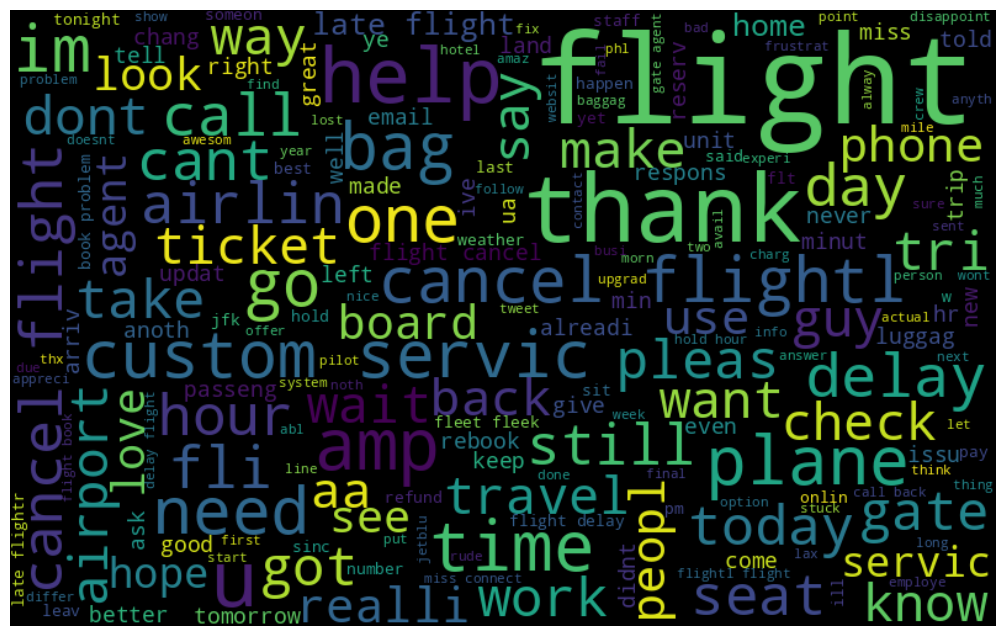

In [22]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_words = " ".join([sentence for sentence in df['clean_tweet']])
wordcloud = WordCloud(width=800, height=500, random_state=42, max_font_size=100).generate(all_words)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [23]:
import pandas as pd
import re
import nltk
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk import FreqDist


df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')
df = df.dropna(subset=['text', 'airline_sentiment'])
df = df.drop_duplicates()

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for word in r:
        input_txt = re.sub(word, '', input_txt)
    return input_txt

def clean_and_tokenize(text):
    text = emoji.demojize(text)
    text = remove_pattern(text, "@[\w]*")
    text = re.sub(r"http\S+", "", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s:]", "", text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_tweet'] = df['text'].apply(clean_and_tokenize)


In [24]:
def clean_and_tokenize(text):
    text = emoji.demojize(text)
    text = remove_pattern(text, "@[\w]*")
    text = re.sub(r"http\S+", "", text)
    text = text.lower()
    text = re.sub(r":[^:\s]*(?::)?", "", text)  # removes emoji tags like :smile:
    text = re.sub(r"[^a-z\s]", "", text)        # keep only letters and spaces
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_tweet'] = df['text'].apply(clean_and_tokenize)


In [25]:
def getAnalysis(sentiment):
    if sentiment.lower() == 'negative':
        return 'Negative'
    elif sentiment.lower() == 'neutral':
        return 'Neutral'
    else:
        return 'Positive'

df['Analysis'] = df['airline_sentiment'].apply(getAnalysis)

In [26]:
df[['airline_sentiment', 'Analysis']].head()

,airline_sentiment,Analysis
0,neutral,Neutral
1,positive,Positive
2,neutral,Neutral
3,negative,Negative
4,negative,Negative


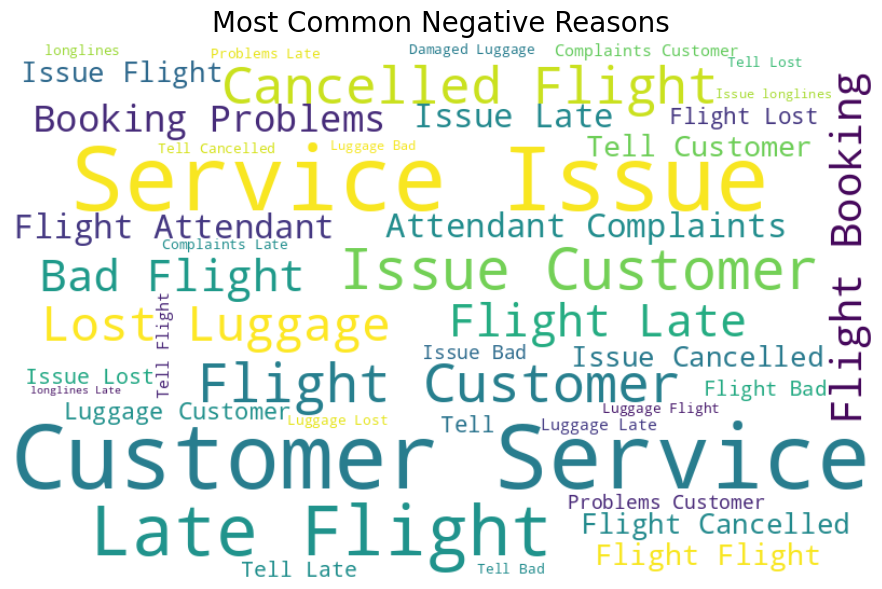

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(text, title):    
    allWords = ' '.join([str(t) for t in text if pd.notnull(t)])
    wordCloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(allWords)
    plt.figure(figsize=(15, 7))
    plt.imshow(wordCloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# WordCloud for negativereason column
create_wordcloud(df['negativereason'], 'Most Common Negative Reasons')


In [28]:
all_words = " ".join(df['clean_tweet'])
word_list = all_words.split()

freq = FreqDist(word_list)

d = pd.DataFrame({
    'Word': list(freq.keys()),
    'Count': list(freq.values())
})

d = d.sort_values(by='Count', ascending=False)
d.head()
all_words = " ".join(df['clean_tweet'])
word_list = all_words.split()

freq = FreqDist(word_list)

d = pd.DataFrame({
    'Word': list(freq.keys()),
    'Count': list(freq.values())
})

d = d.sort_values(by='Count', ascending=False)
d.head()


,Word,Count
31,flight,4799
94,thank,1683
181,get,1616
57,hour,1148
403,cancel,1050


In [29]:
stop_words = set(stopwords.words('english'))
stop_words.update(['get', 'thank'])  # add custom words to ignore
def clean_and_tokenize(text):
    text = emoji.demojize(text)
    text = remove_pattern(text, "@[\w]*")
    text = re.sub(r"http\S+", "", text)
    text = text.lower()
    text = re.sub(r":[^:\s]*(?::)?", "", text)  # remove emoji tags like :airplane:
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_tweet'] = df['text'].apply(clean_and_tokenize)


In [30]:
import nltk
from nltk import FreqDist
import pandas as pd

# Filter only negative tweets
negative_df = df[df['airline_sentiment'] == 'negative']

# Combine all words from clean_tweet column
negative_words = " ".join(negative_df['clean_tweet']).split()

# Get word frequency
freq = FreqDist(negative_words)

# Create DataFrame
d = pd.DataFrame({
    'Word': list(freq.keys()),
    'Count': list(freq.values())
})

# Sort and show top results
d = d.sort_values(by='Count', ascending=False)
d.head()


,Word,Count
16,flight,3568
148,hour,1094
189,cancel,915
186,delay,888
171,custom,773


In [31]:
import pandas as pd
import re

df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

def cleanTweets(text):
    text = re.sub('@[A-Za-z0-9_]+', '', text)
    text = re.sub('#','',text)
    text = re.sub('RT[\s]+','',text)
    text = re.sub('https?:\/\/\S+', '', text)
    text = re.sub('\n',' ',text)
    return text

df['cleanedTweets'] = df['text'].apply(cleanTweets)

df[['text', 'cleanedTweets']].head()


,text,cleanedTweets
0,@VirginAmerica What @dhepburn said.,What said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


In [32]:
# Create a pivot table for counting each sentiment
pivot = pd.pivot_table(df, values='tweet_id', index='airline', columns='airline_sentiment', aggfunc='count', fill_value=0)

# Print the result
print(pivot)

airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152


In [33]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report



df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www.\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    return " ".join([word for word in tokens if word not in stop_words])

df['clean_text'] = df['text'].apply(clean_text)

vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df['clean_text'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['airline_sentiment'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7810792349726776
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1889
           1       0.59      0.50      0.54       580
           2       0.71      0.72      0.72       459

    accuracy                           0.78      2928
   macro avg       0.72      0.70      0.71      2928
weighted avg       0.77      0.78      0.78      2928



In [34]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
class_labels = label_encoder.classes_
topn = 10  # Number of top words per class

for i, label in enumerate(class_labels):
    top_features = np.argsort(nb_model.feature_log_prob_[i])[-topn:]
    top_words = [feature_names[j] for j in top_features][::-1]
    print(f"\nTop words for '{label}':")
    print(top_words)


Top words for 'negative':
['flight', 'united', 'usairways', 'americanair', 'southwestair', 'jetblue', 'cancelled', 'service', 'hours', 'help']

Top words for 'neutral':
['united', 'jetblue', 'southwestair', 'flight', 'americanair', 'usairways', 'virginamerica', 'need', 'help', 'flights']

Top words for 'positive':
['thanks', 'jetblue', 'southwestair', 'united', 'thank', 'flight', 'americanair', 'usairways', 'great', 'service']


In [35]:
import pandas as pd
import numpy as np

feature_names = vectorizer.get_feature_names_out()
class_labels = label_encoder.classes_
topn = 10

table_data = {}

for i, label in enumerate(class_labels):
    top_features = np.argsort(nb_model.feature_log_prob_[i])[-topn:]
    top_words = [feature_names[j] for j in top_features][::-1]
    table_data[label] = top_words

top_words_df = pd.DataFrame(table_data)
top_words_df.index = [f"Rank {i+1}" for i in range(topn)]

top_words_df

,negative,neutral,positive
Rank 1,flight,united,thanks
Rank 2,united,jetblue,jetblue
Rank 3,usairways,southwestair,southwestair
Rank 4,americanair,flight,united
Rank 5,southwestair,americanair,thank
Rank 6,jetblue,usairways,flight
Rank 7,cancelled,virginamerica,americanair
Rank 8,service,need,usairways
Rank 9,hours,help,great
Rank 10,help,flights,service


Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.93      0.88      1889
     neutral       0.66      0.48      0.56       580
    positive       0.79      0.63      0.70       459

    accuracy                           0.80      2928
   macro avg       0.76      0.68      0.71      2928
weighted avg       0.79      0.80      0.78      2928



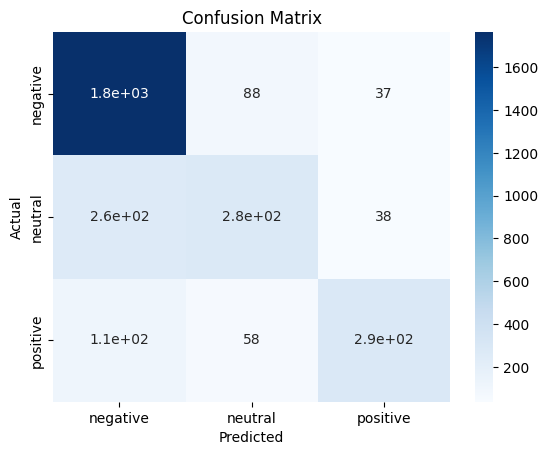

Model and vectorizer saved successfully.


In [36]:
#safyah and mais

import pandas as pd # For handling the dataset
import joblib # For saving and loading model/vectorizer files
import seaborn as sns # For plotting the confusion matrix
import matplotlib.pyplot as plt # For showing plots
from sklearn.model_selection import train_test_split # For splitting the data
from sklearn.feature_extraction.text import TfidfVectorizer # For converting text to numbers
from sklearn.linear_model import LogisticRegression # The ML model used
from sklearn.metrics import classification_report, confusion_matrix # To evaluate the model

# Load the dataset from the CSV file
df = pd.read_csv("/kaggle/input/twitter-airline-sentiment/Tweets.csv")

# Keep only the text and sentiment columns
df = df[['text', 'airline_sentiment']]

# Remove any missing (NaN) values
df.dropna(inplace=True)

# Filter to keep only 'positive', 'neutral', and 'negative' labels
df = df[df['airline_sentiment'].isin(['positive', 'neutral', 'negative'])]

# Split data into input (X) and label (y)
X = df['text']
y = df['airline_sentiment']

df = df[df['airline_sentiment'].isin(['positive', 'neutral', 'negative'])]

# Split data into input (X) and label (y)
X = df['text']
y = df['airline_sentiment']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text into TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8) # Remove common stopwords
X_train_vec = vectorizer.fit_transform(X_train) # Learn vocab from train data and transform it
X_test_vec = vectorizer.transform(X_test) # Only transform test data using same vocab

# Create and train a logistic regression model
model = LogisticRegression(max_iter=1000) # Increase max_iter so it has time to converge
model.fit(X_train_vec, y_train) # Train the model

# Use the model to predict labels on the test set
y_pred = model.predict(X_test_vec)

# Print a performance report (precision, recall, F1-score, accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Draw a heatmap to show confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues',
xticklabels=model.classes_, yticklabels=model.classes_)

# Add labels and title to the confusion matrix plot
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show() # Display the plot

# Save the trained model and vectorizer for production use
joblib.dump(model, "sentiment_model.pkl") # Save model to a .pkl file
joblib.dump(vectorizer, "tfidf_vectorizer.pkl") # Save vectorizer
print("Model and vectorizer saved successfully.")

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
file_path = '/kaggle/input/twitter-airline-sentiment/Tweets.csv'
df = pd.read_csv(file_path)

# Use only relevant columns
df = df[['text', 'airline_sentiment']]

# Optional: Drop neutral class if you want binary classification
# df = df[df['airline_sentiment'] != 'neutral']

# Split data
X = df['text']
y = df['airline_sentiment']

# Convert text to numerical features using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7923497267759563

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.92      0.87      1889
     neutral       0.64      0.48      0.55       580
    positive       0.78      0.66      0.71       459

    accuracy                           0.79      2928
   macro avg       0.75      0.69      0.71      2928
weighted avg       0.78      0.79      0.78      2928



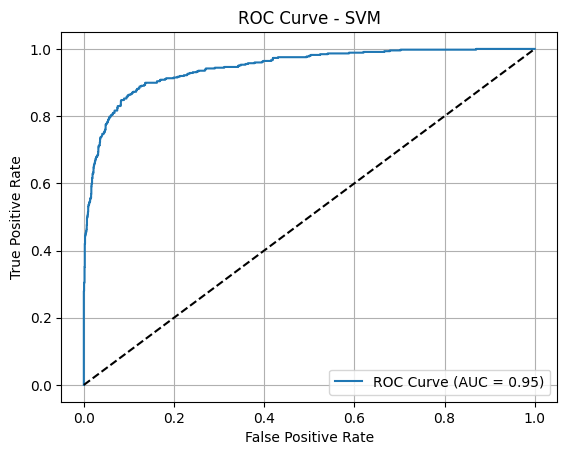

Confusion Matrix:
 [[1803   59]
 [ 137  310]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.93      0.97      0.95      1862
    positive       0.84      0.69      0.76       447

    accuracy                           0.92      2309
   macro avg       0.88      0.83      0.85      2309
weighted avg       0.91      0.92      0.91      2309



In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Load and clean data
df = pd.read_csv("/kaggle/input/twitter-airline-sentiment/Tweets.csv")
df = df[['text', 'airline_sentiment']]
df.dropna(inplace=True)
df = df[df['airline_sentiment'].isin(['positive', 'negative'])]

# Encode sentiment labels BEFORE splitting
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])

# Prepare features and labels
X = df['text']
y = df['label']  # Already encoded

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train SVM with probability=True for ROC curve
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Predict probabilities
y_probs = svm_model.predict_proba(X_test_tfidf)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Confusion Matrix and Report
y_pred = svm_model.predict(X_test_tfidf)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [39]:
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Basic cleaning
df['clean_text'] = df['text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)

# Encode sentiment labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['airline_sentiment'])

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['clean_text'])

# Cross-validation settings
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_scores = cross_val_score(log_model, X, y, cv=kfold, scoring='accuracy')

# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')  # Linear kernel is usually good for text data
svm_scores = cross_val_score(svm_model, X, y, cv=kfold, scoring='accuracy')

# Print results
print("Logistic Regression CV Scores:", log_scores)
print("Logistic Regression Average Accuracy:", log_scores.mean())
print("SVM CV Scores:", svm_scores)
print("SVM Average Accuracy:", svm_scores.mean())


Logistic Regression CV Scores: [0.79303279 0.76844262 0.78756831 0.76331967 0.76605191]
Logistic Regression Average Accuracy: 0.7756830601092897
SVM CV Scores: [0.79815574 0.77698087 0.79098361 0.76571038 0.7704918 ]
SVM Average Accuracy: 0.7804644808743169


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Keep only the necessary columns
df = df[['text', 'airline_sentiment']]

# Drop missing values
df.dropna(inplace=True)

# Filter only 'positive' and 'negative' sentiments
df = df[df['airline_sentiment'].isin(['positive', 'negative'])]

# Encode sentiment labels: positive -> 1, negative -> 0
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])

# Define input features and target
X = df['text']
y = df['label']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train the Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = nb_model.predict(X_test_tfidf)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8497184928540493

Confusion Matrix:
 [[1861    1]
 [ 346  101]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.84      1.00      0.91      1862
    positive       0.99      0.23      0.37       447

    accuracy                           0.85      2309
   macro avg       0.92      0.61      0.64      2309
weighted avg       0.87      0.85      0.81      2309



In [41]:
#Khuzama
import pandas as pd  # Import pandas 

# Load the dataset from the Kaggle input directory
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Function to get the airline with the most mentions
def max_airline_used(df):
    airline_counts = df['airline'].value_counts()
    return airline_counts.idxmax()

# Function to get the least mentioned negative reason
def min_negative_reason(df):
    negative_reason_counts = df['negativereason'].value_counts()
    return negative_reason_counts.idxmin()

# Function to calculate the average sentiment score
def average_airline_sentiment(df):
    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    df['sentiment_numeric'] = df['airline_sentiment'].map(sentiment_map)
    return df['sentiment_numeric'].mean()

# Call functions and print the results
max_airline = max_airline_used(df)
print("Airline with the most mentions:", max_airline)

min_negative = min_negative_reason(df)
print("Least mentioned negative reason:", min_negative)

avg_sentiment = average_airline_sentiment(df)
print("Average airline sentiment:", avg_sentiment)


Airline with the most mentions: United
Least mentioned negative reason: Damaged Luggage
Average airline sentiment: -0.4655054644808743


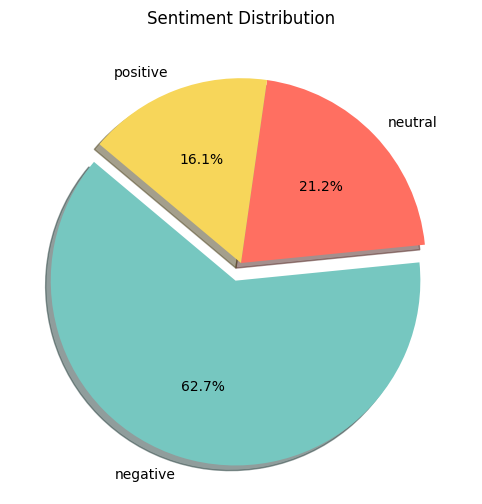

In [42]:
#Leen
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/kaggle/input/twitter-airline-sentiment/Tweets.csv'
data = pd.read_csv(dataset_path)

# Assuming the sentiment column is named 'airline_sentiment'
# This column should contain values like "positive", "negative", and "neutral"
sentiment_counts = data['airline_sentiment'].value_counts()

# Prepare data for the pie chart
labels = sentiment_counts.index # Names of the sentiment categories
sizes = sentiment_counts.values # Number of tweets in each category
colors = ['#76c7c0', '#ff6f61', '#f7d65a'] # Colors for each category
explode = (0.1, 0, 0) # Slightly separate the first slice (optional)

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
sizes, labels=labels, colors=colors, autopct='%1.1f%%',
startangle=140, explode=explode, shadow=True
)
plt.title('Sentiment Distribution')
plt.show()
#it will give us a pie chart that illustrates the proportion of positive, negative, and neutral sentiments among the tweets. This gives a quick visual overview of overall customer perception.

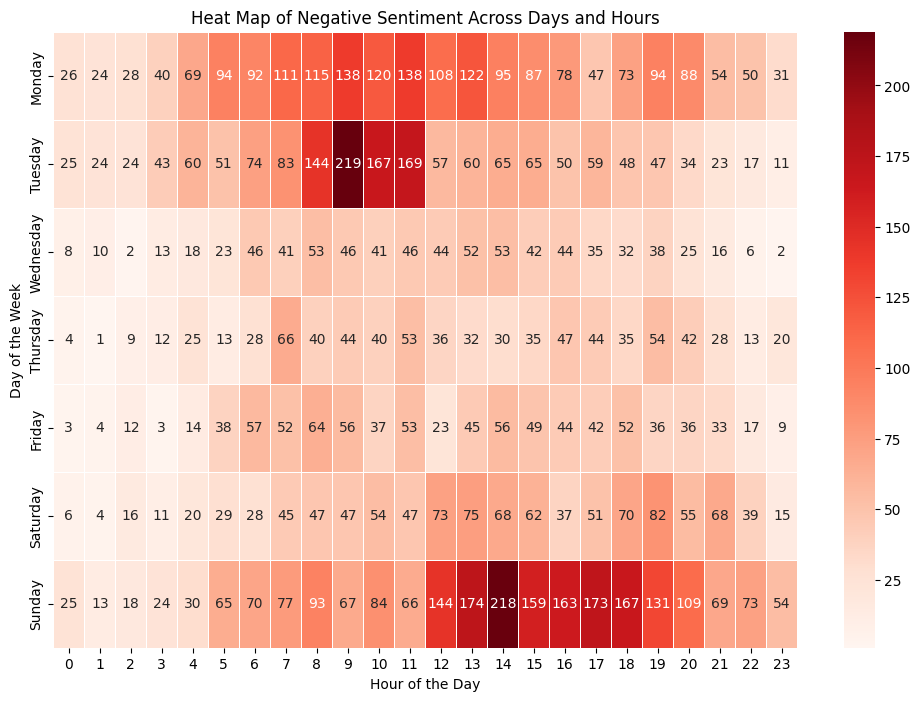

In [43]:
#Leen
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/kaggle/input/twitter-airline-sentiment/Tweets.csv'
data = pd.read_csv(dataset_path)

# Parse the 'tweet_created' column to datetime if available
# Assuming the column 'tweet_created' contains the timestamp of tweets
data['tweet_created'] = pd.to_datetime(data['tweet_created'])

# Extract the day of the week and hour of the day
data['day_of_week'] = data['tweet_created'].dt.day_name() # e.g., Monday, Tuesday
data['hour_of_day'] = data['tweet_created'].dt.hour # e.g., 0-23

# Create a pivot table to count sentiments by day and hour
pivot_table = data.pivot_table(
index='day_of_week', # Days of the week as rows
columns='hour_of_day', # Hours of the day as columns
values='airline_sentiment', # Sentiment column
aggfunc=lambda x: (x == 'negative').sum() # Counting negative sentiments (can be changed to positive/neutral)
)

# Reorder days of the week for better readability
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days_order)

# Plot the heat map
plt.figure(figsize=(12, 8))
sns.heatmap(
pivot_table,
cmap='Reds', # Color palette for intensity
annot=True, # Display the numbers in the cells
fmt='d', # Integer format
linewidths=0.5
)
plt.title('Heat Map of Negative Sentiment Across Days and Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.show()
#it will give us a heat map that depict the intensity of sentiment across different times of the day or days of the week, helping to identify peak times of customer interaction and sentiment.

Dataset loaded successfully.
Columns in the dataset: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


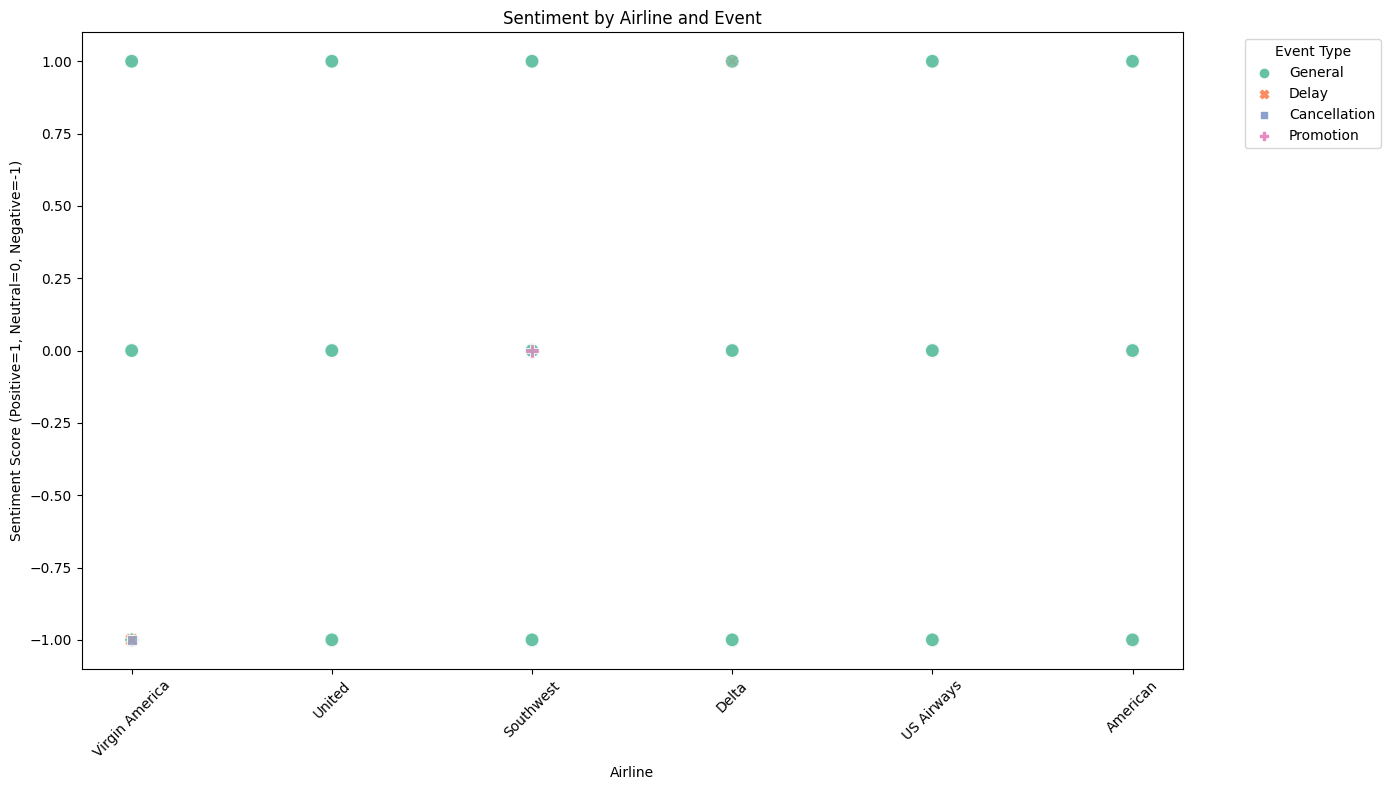

In [44]:
#leen
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/kaggle/input/twitter-airline-sentiment/Tweets.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("The specified file was not found. Please check the file path.")
    exit()

# Display column names to verify structure
print("Columns in the dataset:", df.columns)

# Check for required columns
required_columns = ['airline', 'airline_sentiment', 'text']
for col in required_columns:
    if col not in df.columns:
        print(f"Missing column: {col}. Please ensure the dataset has this column.")
        exit()

# Data Preprocessing
# Remove missing values
df = df.dropna(subset=required_columns)

# Verify sentiment values
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_score'] = df['airline_sentiment'].map(sentiment_map)
if df['sentiment_score'].isnull().any():
    print("Unexpected sentiment values found. Please ensure the sentiment column contains only 'positive', 'neutral', or 'negative'.")
    exit()

# Define events based on keywords in the tweet text
def classify_event(text):
    text = text.lower()
    if 'cancellation' in text or 'cancelled' in text:
        return 'Cancellation'
    elif 'promotion' in text or 'offer' in text:
        return 'Promotion'
    elif 'delay' in text or 'delayed' in text:
        return 'Delay'
    else:
        return 'General'

df['event'] = df['text'].apply(classify_event)

# Plot Sentiment by Airline and Event
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df,
    x='airline',
    y='sentiment_score',
    hue='event',
    style='event',
    palette='Set2',
    s=100,
    alpha=0.8
)
plt.title('Sentiment by Airline and Event')
plt.xlabel('Airline')
plt.ylabel('Sentiment Score (Positive=1, Neutral=0, Negative=-1)')
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

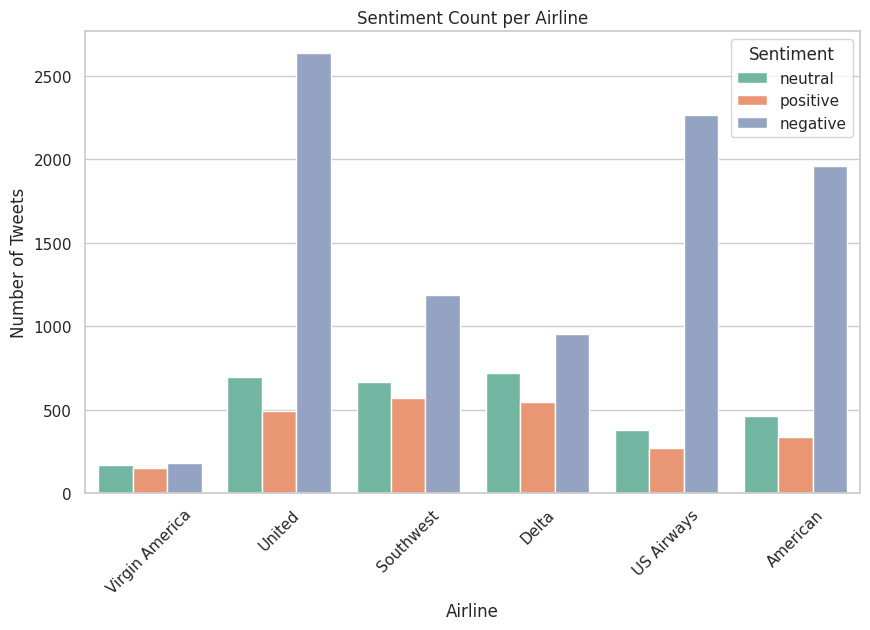

<Figure size 1200x600 with 0 Axes>

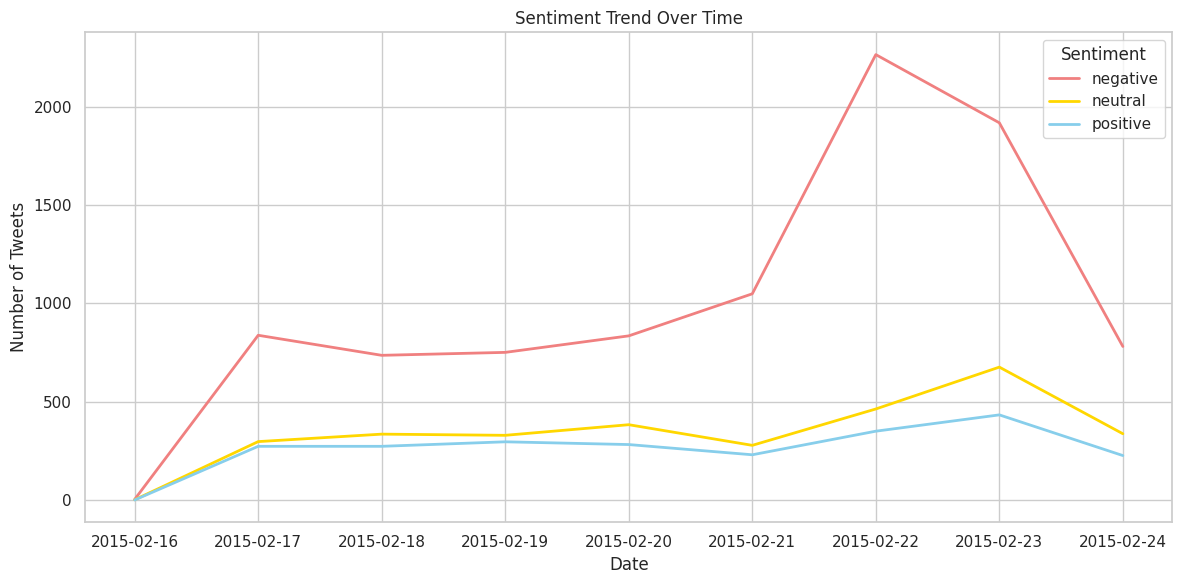

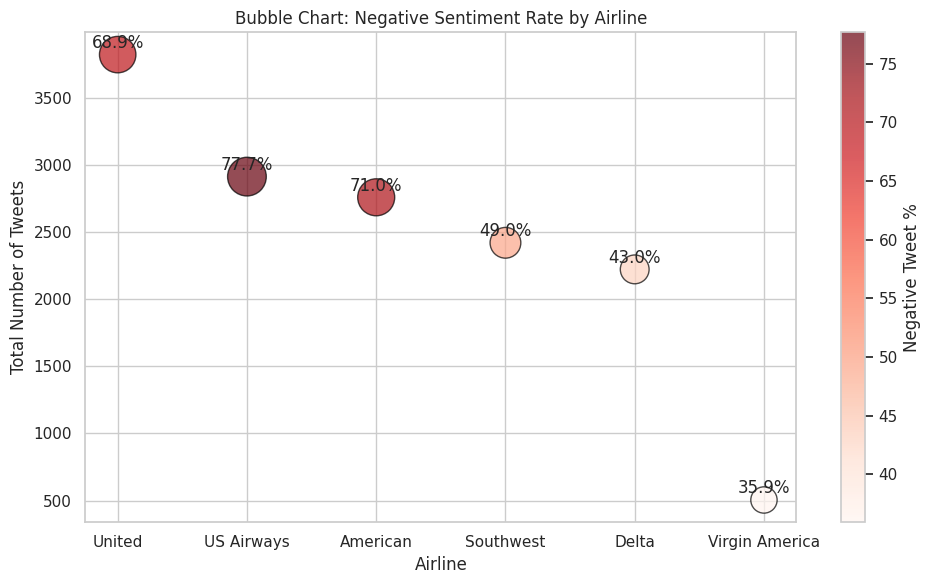

In [45]:
#sarah Alsadah
#Bar Chart – Sentiment Count per Airline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Set plot style
sns.set(style='whitegrid')

# Create the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='airline', hue='airline_sentiment', palette='Set2')

# Add title and labels
plt.title('Sentiment Count per Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

# Show the plot
plt.show()




#Line Chart – Sentiment Trend Over Time

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Convert tweet_created to datetime format
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

# Extract just the date (drop the time part)
df['date'] = df['tweet_created'].dt.date

# Group by date and sentiment
trend_data = df.groupby(['date', 'airline_sentiment']).size().unstack().fillna(0)

# Plot the line chart
plt.figure(figsize=(12,6))
trend_data.plot(kind='line', linewidth=2, figsize=(12,6), color=['lightcoral', 'gold', 'skyblue'])

# Add titles and labels
plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid(True)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()



#Python Example – Bubble Chart: Negative Sentiment Share by Airline

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/kaggle/input/twitter-airline-sentiment/Tweets.csv')

# Count total and negative tweets per airline
total_counts = df['airline'].value_counts()
negative_counts = df[df['airline_sentiment'] == 'negative']['airline'].value_counts()

# Create a DataFrame for plotting
bubble_df = pd.DataFrame({
    'Airline': total_counts.index,
    'Total_Tweets': total_counts.values,
    'Negative_Tweets': negative_counts[total_counts.index].fillna(0).values
})

# Calculate percentage of negative tweets
bubble_df['Negative_Rate'] = bubble_df['Negative_Tweets'] / bubble_df['Total_Tweets'] * 100

# Plot
plt.figure(figsize=(10,6))
plt.scatter(
    bubble_df['Airline'], 
    bubble_df['Total_Tweets'], 
    s=bubble_df['Negative_Rate'] * 10,  # Bubble size
    c=bubble_df['Negative_Rate'], 
    cmap='Reds', 
    alpha=0.7,
    edgecolors='black'
)

# Add labels
for i in range(len(bubble_df)):
    plt.text(bubble_df['Airline'][i], bubble_df['Total_Tweets'][i] + 50, f"{bubble_df['Negative_Rate'][i]:.1f}%", ha='center')

# Titles and labels
plt.title('Bubble Chart: Negative Sentiment Rate by Airline')
plt.xlabel('Airline')
plt.ylabel('Total Number of Tweets')
plt.colorbar(label='Negative Tweet %')
plt.tight_layout()
plt.show()